# Tutorial 10 — Graphite: hexagonal disentanglement

The waw-native reimagining of Wannier90 tutorial 10. **AB-stacked graphite** is the first tutorial with a **non-orthogonal (hexagonal)** lattice and **mixed per-atom projections** — but unlike a free-standing graphene sheet (which needs an artificial vacuum gap and hits the out-of-plane spread problem noted in the bonus aluminium-chain notebook), bulk graphite is a genuine **3-D periodic crystal**: the weak interlayer bonding still gives a complete finite-difference $b$-vector shell in all three directions, so no special handling is needed.

10 Wannier functions come from disentangling the 20 lowest bands: 6 in-plane $sp^2$ $\sigma$-bonds + 4 out-of-plane $p_z$ $\pi$ orbitals. SCDM's energy-window projection (`erfc`) builds these directly from the band manifold, without needing the mixed `C1:sp2;pz` / `C2:pz` analytic projection blocks the original tutorial uses.

In [1]:
import os, sys, pathlib
import numpy as np
import matplotlib.pyplot as plt

# locate the repo root (the folder containing the `waw` package), so the
# notebook runs from anywhere
HERE = pathlib.Path.cwd()
REPO = HERE
while not (REPO / 'waw').exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

import waw
from waw.interfaces import quantum_espresso as qe   # the direct-input QE driver
from waw.interfaces.ase.driver import wannierize
from waw.units import BOHR_TO_ANG, HARTREE_TO_EV
from waw.vis import plot_bands, BandSeries

PSEUDO_DIR = REPO / 'workflows' / 'pseudos'   # shared across workflows/, not w90tutorial-specific
NCORES = 16
waw.set_num_threads(NCORES)                  # use many cores for waw's batched linear algebra
print('waw', 'threads =', waw.get_num_threads(), '| repo', REPO)

waw threads = 16 | repo /aims_data/miguel/nas-data001/claude/wannier


### 1. Structure and converged DFT
Hexagonal AB-stacked graphite, $a = 2.46$ Å, $c = 6.8$ Å, 4 atoms/cell. Metallic (semimetal) — cold smearing. 20 bands on a $4\times4\times4$ mesh, SCDM `erfc` weighted around the target manifold ($\mu=14.5$, $\sigma=3$ eV).

In [2]:
from ase import Atoms

cell = [[2.1304215583, -1.2299994602, 0.0],
        [0.0,           2.4599989204, 0.0],
        [0.0,           0.0,          6.8]]
frac = [[0, 0, 0.25], [0, 0, 0.75], [1/3, 2/3, 0.25], [-1/3, -2/3, 0.75]]
atoms = Atoms('C4', scaled_positions=frac, cell=cell, pbc=True)
MP_GRID = (4, 4, 4)
WORK = HERE / 'runs' / 'graphite'
SMEAR = dict(occupations='smearing', smearing='cold', degauss=0.02)

ov = qe.generate_overlaps(
    atoms, MP_GRID, WORK, 'graphite',
    ecutwfc=50, scf_kpts=(10, 10, 10), nbnd=22, num_wann=10,
    scdm_entanglement='erfc', scdm_mu=14.5, scdm_sigma=3.0,
    system_extra=SMEAR,
    pseudopotentials={'C': 'C.upf'}, pseudo_dir=PSEUDO_DIR, ncores=NCORES,
    rerun_scf=False,          # reuse a completed SCF in runs/graphite/ if present
)
print('overlap shapes:', {k: np.shape(v) for k, v in ov.items()
                          if k in ('mmn', 'amn', 'eig')})

overlap shapes: {'mmn': (64, 8, 22, 22), 'amn': (64, 22, 10), 'eig': (64, 22)}


### 2. Disentangle + Wannierise
**Frozen window** to 9.8 eV (the occupied $\sigma+\pi$ manifold kept exactly), **outer window** to 19.2 eV (the same values Wannier90 tutorial 10 uses) — the disentanglement picks the optimally-connected 10-dimensional subspace inside.

In [3]:
result = wannierize(
    atoms, MP_GRID, ov['kpts'],
    mmn=ov['mmn'], amn=ov['amn'], eig=ov['eig'],
    nnkpts=ov['nnkpts'], g_vectors=ov['g_vectors'],
    nw=10, outer_window=(-1e3, 19.2), frozen_window=(-1e3, 9.8),
    n_restarts=3, dis_n_iter=1000, n_iter=6000, verbose=False,
)
omega_I = result.dis.omega_i * BOHR_TO_ANG**2
omega = result.omega_final * BOHR_TO_ANG**2
spreads = result.spreads_bohr2 * BOHR_TO_ANG**2
print(f'Omega_I     = {omega_I:.4f} Ang^2   (Wannier90 tutorial10: 5.764)')
print(f'Omega_total = {omega:.4f} Ang^2   (Wannier90 tutorial10: 7.381)')
print('per-WF spreads (Ang^2):', spreads.round(3))

Omega_I     = 5.5822 Ang^2   (Wannier90 tutorial10: 5.764)
Omega_total = 7.1477 Ang^2   (Wannier90 tutorial10: 7.381)
per-WF spreads (Ang^2): [0.559 0.559 0.946 0.559 0.952 0.946 0.559 0.559 0.559 0.952]


$\Omega_I$ matches the Wannier90 reference closely (the residual is the PseudoDojo vs. historical norm-conserving pseudo, as in the other notebooks). The spreads split into two families — the more localised in-plane $\sigma$-bonds and the more diffuse out-of-plane $\pi$ orbitals — matching the tutorial's `sp2` + `pz` picture even though SCDM never saw those orbital labels.

### 3. Interpolated band structure
ASE's standard hexagonal path for this cell. Inside the frozen window (shaded) the 10-band Wannier model reproduces the DFT bands exactly.

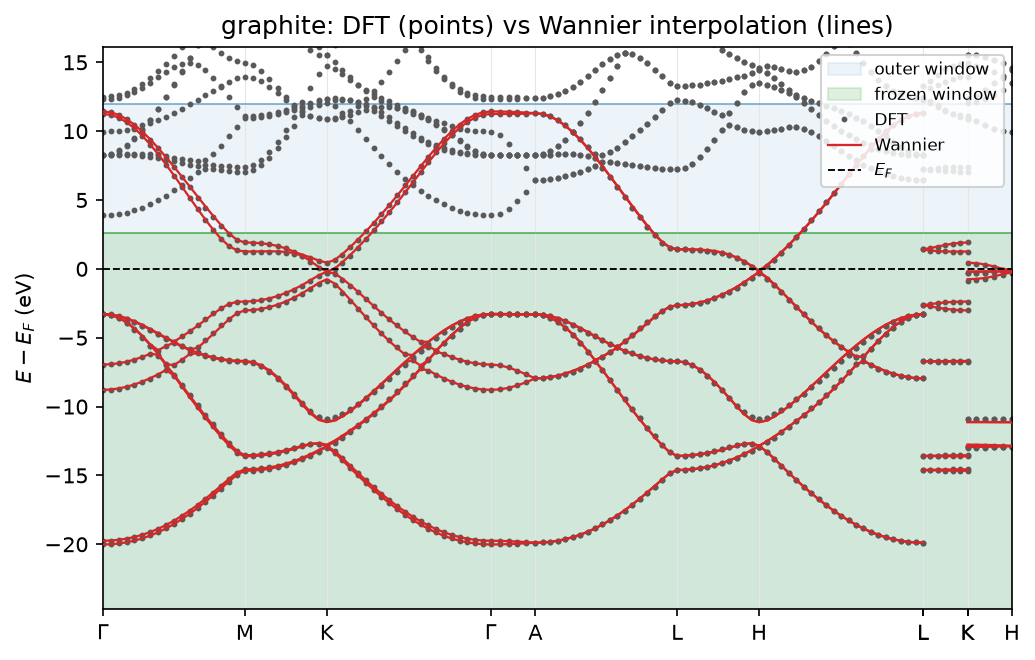

on the Wannier mesh, inside the frozen window: max 0.000 meV, rms 0.000 meV over 566 states


In [4]:
from waw.interfaces.ase.structure import band_path
from waw.core.hamiltonian import interpolate_bands
from waw.interfaces.quantum_espresso import bands_along_path
from waw.analysis.bands import mesh_fidelity
from waw.vis import plot_wannierization_windows

E_F = ov['fermi_energy']
bp = band_path(atoms, npoints=120)
xcoords, xspecial, labels = bp.get_linear_kpoint_axis()
bands = interpolate_bands(result.hr, bp.kpts) * HARTREE_TO_EV
try:
    dft_bands = bands_along_path(WORK, 'graphite', bp.kpts, ncores=NCORES)
except FileNotFoundError as exc:      # charge density not kept in this run dir
    dft_bands = np.full_like(bands, np.nan)
    print(exc)

fig, ax = plt.subplots(figsize=(7, 4.5), dpi=150)
plot_wannierization_windows(
    ax, xcoords, dft_bands, bands,
    outer_window=(-1e3, 19.2), frozen_window=(-1e3, 9.8), fermi_energy=E_F,
    xticks=xspecial, xticklabels=[l.replace('G', r'$\Gamma$') for l in labels])
ax.set_title('graphite: DFT (points) vs Wannier interpolation (lines)')
plt.tight_layout(); plt.show()

fid = mesh_fidelity(result.hr, ov['kpts'], ov['eig'],
                    window=(-1e3, 9.8), fermi_ev=E_F)
print(f"on the Wannier mesh, inside the frozen window: max {fid['max']:.3f} meV, "
      f"rms {fid['rms']:.3f} meV over {fid['n_states']} states")


The bands show graphite's characteristic weakly-dispersing $\pi$ bands touching near K (the origin of graphene's Dirac cone, gapped open here by the interlayer AB coupling) alongside the deeper $\sigma$-bond manifold.

**Takeaway.** A non-orthogonal lattice and mixed orbital character need no special-casing in the waw-native pipeline — `generate_overlaps` + `wannierize` handle graphite's hexagonal cell exactly like a cubic one, and the periodic (not slab) geometry sidesteps the vacuum-spread issue that blocks a bare graphene monolayer.